# AxBench results

In [7]:
import pandas as pd
from pathlib import Path

cfg = "2b_l10"
# cfg = "2b_l20"
# cfg = "9b_l20"
# cfg = "27b_l21"
# cfg = "g3_12b_l22"
# cfg = "q25_32b_l32"

positions = "all"
# positions = "f2+l2"
# positions = "f4+l4"

obj = "lang"
# obj = "simpo"

intvs = ["add_free"]

# positions = "prompt"
# obj = "none"
# intvs = ["prompt"]

# output_root_dir = Path("/mnt/data/byt", "reft_data", "axbench")
output_root_dir = Path("/home/byt", "reft_data", "axbench")


In [ ]:
from collections import defaultdict
import itertools
import numpy as np


def harmonic_mean(scores):
    # Return 0 if any score is 0 to maintain strict evaluation
    if 0 in scores:
        return 0.0
    return len(scores) / sum(1 / s for s in scores)


def get_overall_score_concept_df(eval_df: pd.DataFrame):
    harmonic_scores = []
    for _, row in eval_df.iterrows():
        mean = harmonic_mean(
            [row["concept_score"], row["relevance_score"], row["fluency_score"]]
        )
        harmonic_scores.append(mean)

    return np.mean(harmonic_scores).item()


def load_results(output_root_dir, cfgs, positions, objs, interventions=("add_free", )):
    res_df = defaultdict(list)

    for k, cfg, obj, pos in itertools.product(interventions, cfgs, objs, positions):
        for concept_id in range(500):
            eval_path = (
                output_root_dir
                / cfg
                / f"outputs_{k}"
                / f"{pos}"
                / obj
                / f"{concept_id}"
                / "eval.parquet"
            )
            if not eval_path.exists():
                continue

            eval_df = pd.read_parquet(eval_path)

            overall_score = get_overall_score_concept_df(eval_df)
            concept_score = eval_df["concept_score"].mean()
            instruct_score = eval_df["relevance_score"].mean()
            fluency_score = eval_df["fluency_score"].mean()

            res_df["method"].append(k)
            res_df["cfg"].append(cfg)
            res_df["objective"].append(obj)
            res_df["position"].append(pos)

            res_df["concept_id"].append(concept_id)
            res_df["concept"].append(eval_df["concept"].iloc[0])
            res_df["overall_score"].append(overall_score)
            res_df["concept_score"].append(concept_score)
            res_df["instruct_score"].append(instruct_score)
            res_df["fluency_score"].append(fluency_score)

    res_df = pd.DataFrame(res_df)
    if len(res_df) == 0:
        return None
    res_df["method"] = res_df["method"].replace(
        ["add_free", "clamp_free"], ["AddInv", "ClampInv"]
    )
    return res_df


In [9]:
res_df = load_results(
    output_root_dir=output_root_dir,
    cfgs=[cfg],
    positions=[positions],
    objs=[obj],
    interventions=intvs,
)
res_df


,method,cfg,objective,position,concept_id,concept,overall_score,concept_score,instruct_score,fluency_score
0,AddInv,2b_l10,lang,all,0,references to specific dates and publication i...,1.24,1.6,1.5,1.0
1,AddInv,2b_l10,lang,all,1,technical specifications related to audio prod...,0.60,0.9,0.7,1.0
2,AddInv,2b_l10,lang,all,2,references to video and multimedia content,1.21,1.3,1.8,1.1
3,AddInv,2b_l10,lang,all,3,references to nudity and related sexual themes,0.84,0.9,1.2,1.0
4,AddInv,2b_l10,lang,all,4,programming constructs related to data managem...,0.46,0.4,1.4,1.1
...,...,...,...,...,...,...,...,...,...,...
495,AddInv,2b_l10,lang,all,495,phrases indicating future intentions or actions,1.09,1.5,1.4,1.0
496,AddInv,2b_l10,lang,all,496,phrases indicating quantity or measurement ass...,0.24,0.2,1.5,1.0
497,AddInv,2b_l10,lang,all,497,mathematical terms and operations related to a...,0.30,0.4,1.1,1.0
498,AddInv,2b_l10,lang,all,498,phrases that emphasize the significance of sma...,1.05,2.0,1.0,1.1


In [ ]:
score_keys = ("overall", "concept", "instruct", "fluency")
for k in score_keys:
    score = res_df[f"{k}_score"].mean()
    std = res_df[f"{k}_score"].std()
    print(f"{k.capitalize()} score:\t{score:.4f} ± {std:.4f}")


In [10]:
score_keys = ("overall", "concept", "instruct", "fluency")
for k in score_keys:
    score = res_df[f"{k}_score"].iloc[:10].mean()
    std = res_df[f"{k}_score"].std()
    print(f"{k.capitalize()} score:\t{score:.4f} ± {std:.4f}")


Overall score:	0.6890 ± 0.3750
Concept score:	0.8600 ± 0.5209
Instruct score:	1.3700 ± 0.3155
Fluency score:	1.0400 ± 0.0730


In [118]:
res_df['overall_score'].max()

np.float64(1.55)

In [119]:
low_df = res_df[res_df["overall_score"] < 0.2].sort_values(
    ["overall_score", "concept_score"],
)[['concept', 'overall_score', 'concept_score']]


In [122]:
import json

metadata = [
    json.loads(l)
    for l in open(
        Path(f"../../data/concept500/prod_{cfg}_v1/generate/metadata.jsonl")
    ).readlines()
]
genres = []
for i, row in low_df.iterrows():
    genres.append(metadata[i]["concept_genres_map"][row["concept"]][0])
low_df["genre"] = genres
low_df = low_df[["concept", "genre", "overall_score", "concept_score"]]
low_df = low_df.sort_values(['overall_score', 'genre'])

print(low_df.to_latex(index=False, float_format="%.2f"))


\begin{tabular}{llrr}
\toprule
concept & genre & overall_score & concept_score \\
\midrule
code-related constructs and functions in programming languages & code & 0.00 & 0.00 \\
markup elements and their attributes in HTML or XML documents & code & 0.00 & 0.00 \\
programming constructs related to range definitions or loops & code & 0.00 & 0.00 \\
end-of-comment markers in code & code & 0.00 & 0.00 \\
underscore characters in variable and function names or parameters & code & 0.00 & 0.20 \\
numerical values and their relationships & math & 0.00 & 0.00 \\
mathematical problem-solving phrases & math & 0.00 & 0.00 \\
string concatenation operations and associated punctuation & code & 0.10 & 0.10 \\
JavaScript methods and properties related to manipulating the DOM's class and style attributes & code & 0.10 & 0.10 \\
types and declarations in programming code & code & 0.10 & 0.10 \\
code fragments that involve accessing or manipulating data structures like arrays and maps & code & 0.10 & 0.2

## Score distribution

In [ ]:
all_df = load_results(
    output_root_dir=output_root_dir,
    cfgs=["2b_l10", "9b_l20", "q25_32b_l32"],
    positions=["all", "f2+l2", "prompt"],
    objs=["lang", "simpo", "none"],
    interventions=["add_free", "prompt"],
)


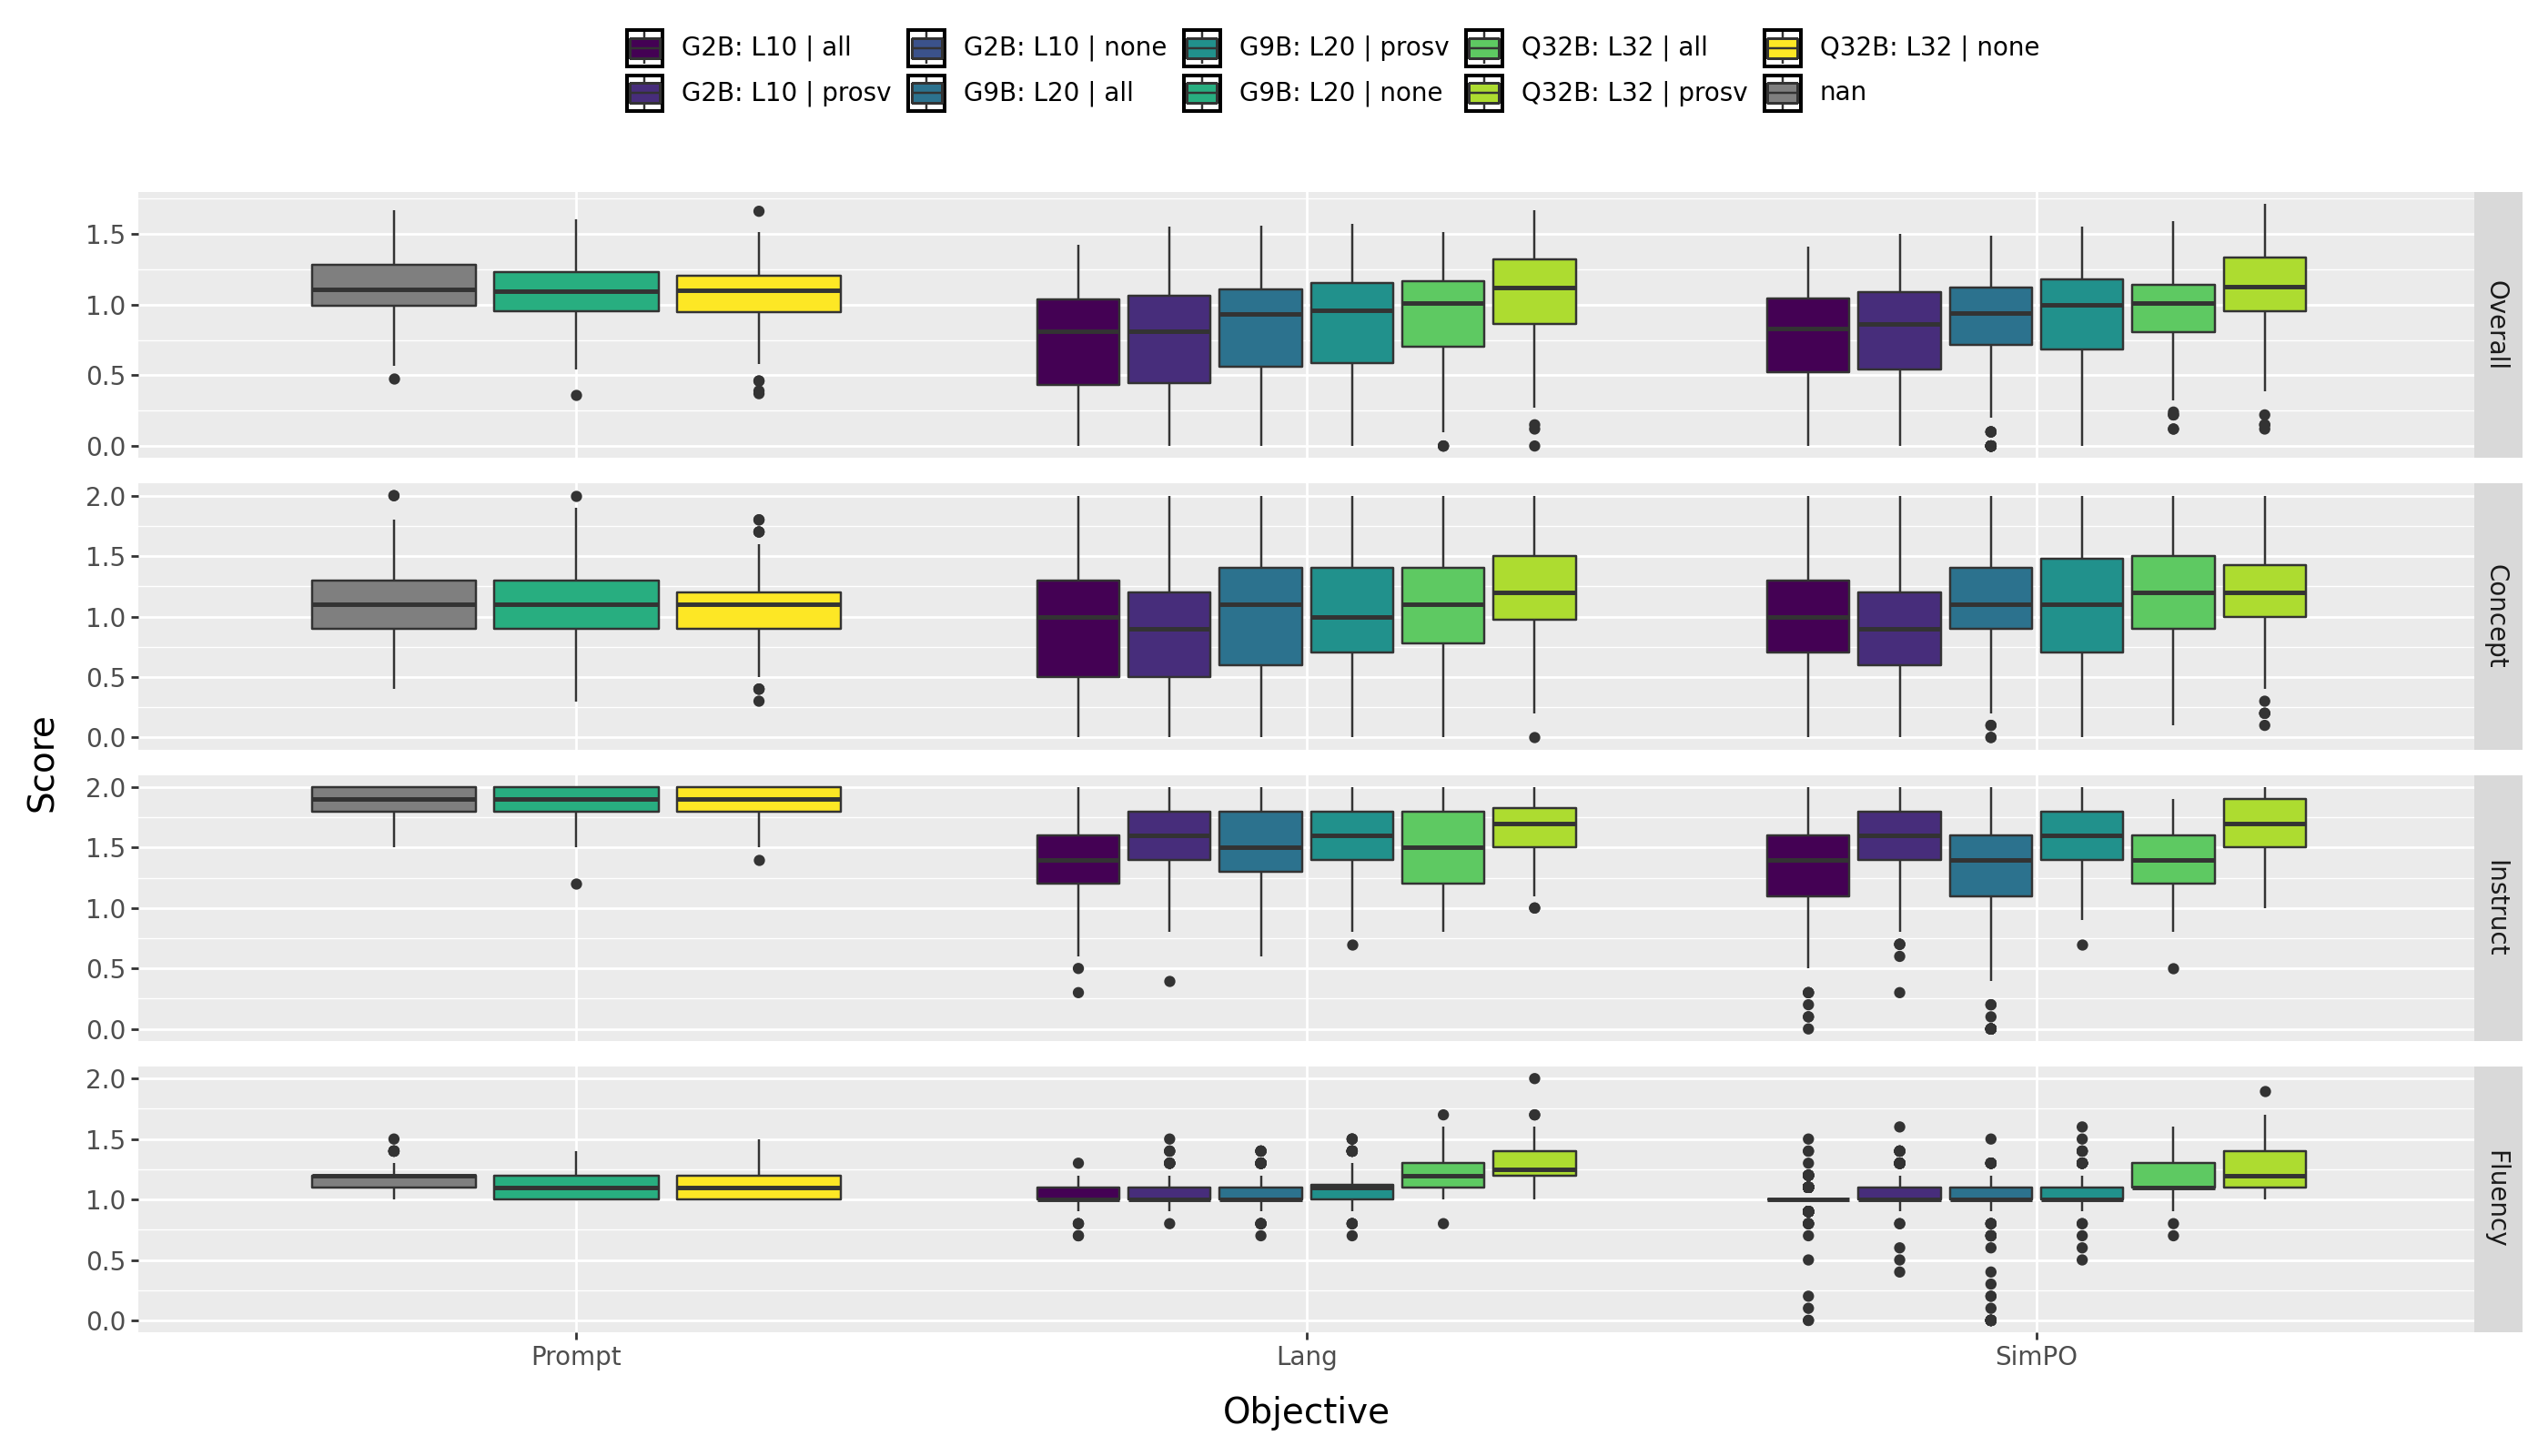

In [167]:
from plotnine import *
import itertools

score_keys = ("overall", "concept", "instruct", "fluency")
tmp_df = all_df.melt(
    id_vars=["cfg", "position", "objective"],
    value_vars=[k + "_score" for k in score_keys],
    var_name="Metric",
    value_name="Score",
)
tmp_df["position"] = tmp_df["position"].replace(['all', 'f2+l2', 'prompt'], ['all', 'prosv', 'none'])
tmp_df["cfg"] = tmp_df["cfg"].replace(["2b_l10", "9b_l20", "q25_32b_l32"], ["G2B: L10", "G9B: L20", "Q32B: L32"])
tmp_df['cfg_position'] = tmp_df['cfg'] + " | " + tmp_df['position']
tmp_df["cfg_position"] = pd.Categorical(
    tmp_df["cfg_position"],
    categories=[c + " | " + p for c, p in itertools.product(["G2B: L10", "G9B: L20", "Q32B: L32"], ["all", "prosv", "none"])],
    ordered=True,
)

tmp_df["objective"] = tmp_df["objective"].replace(["lang", "simpo", "none"], ["Lang", "SimPO", "Prompt"])
tmp_df['objective'] = pd.Categorical(tmp_df["objective"], categories=["Prompt", "Lang", "SimPO"], ordered=True)

tmp_df["Metric"] = tmp_df["Metric"].replace(
    [k + "_score" for k in score_keys], [k.capitalize() for k in score_keys]
)
tmp_df["Metric"] = pd.Categorical(
    tmp_df["Metric"],
    categories=[k.capitalize() for k in score_keys],
    ordered=True,
)

# metric_colors = [ "#472d7b", "#3a5cac", "#39a9bc", "#5dc863", "#b8de29", "#949158", "#fee529", "#ffa600", "#d62828", ]

plot = (
    ggplot(tmp_df, aes(x="objective", y="Score", fill='cfg_position'))
    + facet_grid(rows="Metric", scales='free_y')
    + geom_boxplot()
    # + scale_fill_manual(values=metric_colors)
    + labs(fill="", x="Objective", size=14)
    + theme(
        figure_size=(14, 8),
        legend_position="top",
        legend_box="horizontal",
        legend_key=element_rect(color="black", fill="white", size=0.8),
        legend_text=element_text(size=10),
        axis_text=element_text(size=10),
        axis_title=element_text(size=14),
        strip_text=element_text(size=10),
    )
)
plot


In [197]:
# save_dir = Path('figures/')
# save_dir.mkdir(parents=True, exist_ok=True)
# save_path = save_dir / "summary.pdf"
# plot.save(save_path)


# Factor distribution

In [1]:
import torch
from pathlib import Path

# cfg = "2b_l10"
cfg = "9b_l20"
# cfg = "q25_32b_l32"

# positions = "all"
positions = "f2+l2"
# positions = "f4+l4"

# obj = "lang"
obj = "simpo"

intvs = ["add_free"]

# positions = "prompt"
# obj = "none"
# intvs = ["prompt"]

output_root_dir = Path("/mnt/data/byt", "reft_data", "axbench")


In [2]:
from collections import defaultdict
import itertools
import pandas as pd


def load_ckpts(output_root_dir, cfgs, positions, objs, interventions=("add_free",)):
    res_df = defaultdict(list)

    for k, cfg, obj, pos in itertools.product(interventions, cfgs, objs, positions):
        for concept_id in range(500):
            eval_path = (
                output_root_dir
                / cfg
                / f"outputs_{k}"
                / f"{pos}"
                / obj
                / f"{concept_id}"
                / "state_dict.pt"
            )
            if not eval_path.exists():
                continue

            state_dict = torch.load(eval_path, map_location="cpu")
            if cfg == "2b_l10":
                l = 10
            elif cfg == "9b_l20":
                l = 20
            elif cfg == "q25_32b_l32":
                l = 32
            else:
                l = None
            factor = state_dict[f"model.layers.{l}"]["factor"].item()
            vec_norm = state_dict[f"model.layers.{l}"]["proj.weight"].norm().item()

            res_df["method"].append(k)
            res_df["cfg"].append(cfg)
            res_df["objective"].append(obj)
            res_df["position"].append(pos)

            res_df["concept_id"].append(concept_id)
            res_df["factor"].append(factor)
            res_df["l2norm"].append(vec_norm)

    res_df = pd.DataFrame(res_df)
    if len(res_df) == 0:
        return None
    res_df["method"] = res_df["method"].replace(
        ["add_free", "clamp_free"], ["AddInv", "ClampInv"]
    )
    return res_df


In [4]:
all_df = load_ckpts(
    output_root_dir=output_root_dir,
    cfgs=["2b_l10", "9b_l20", "q25_32b_l32"],
    positions=["all", "f2+l2"],
    objs=["lang", "simpo"],
    interventions=["add_free"],
)


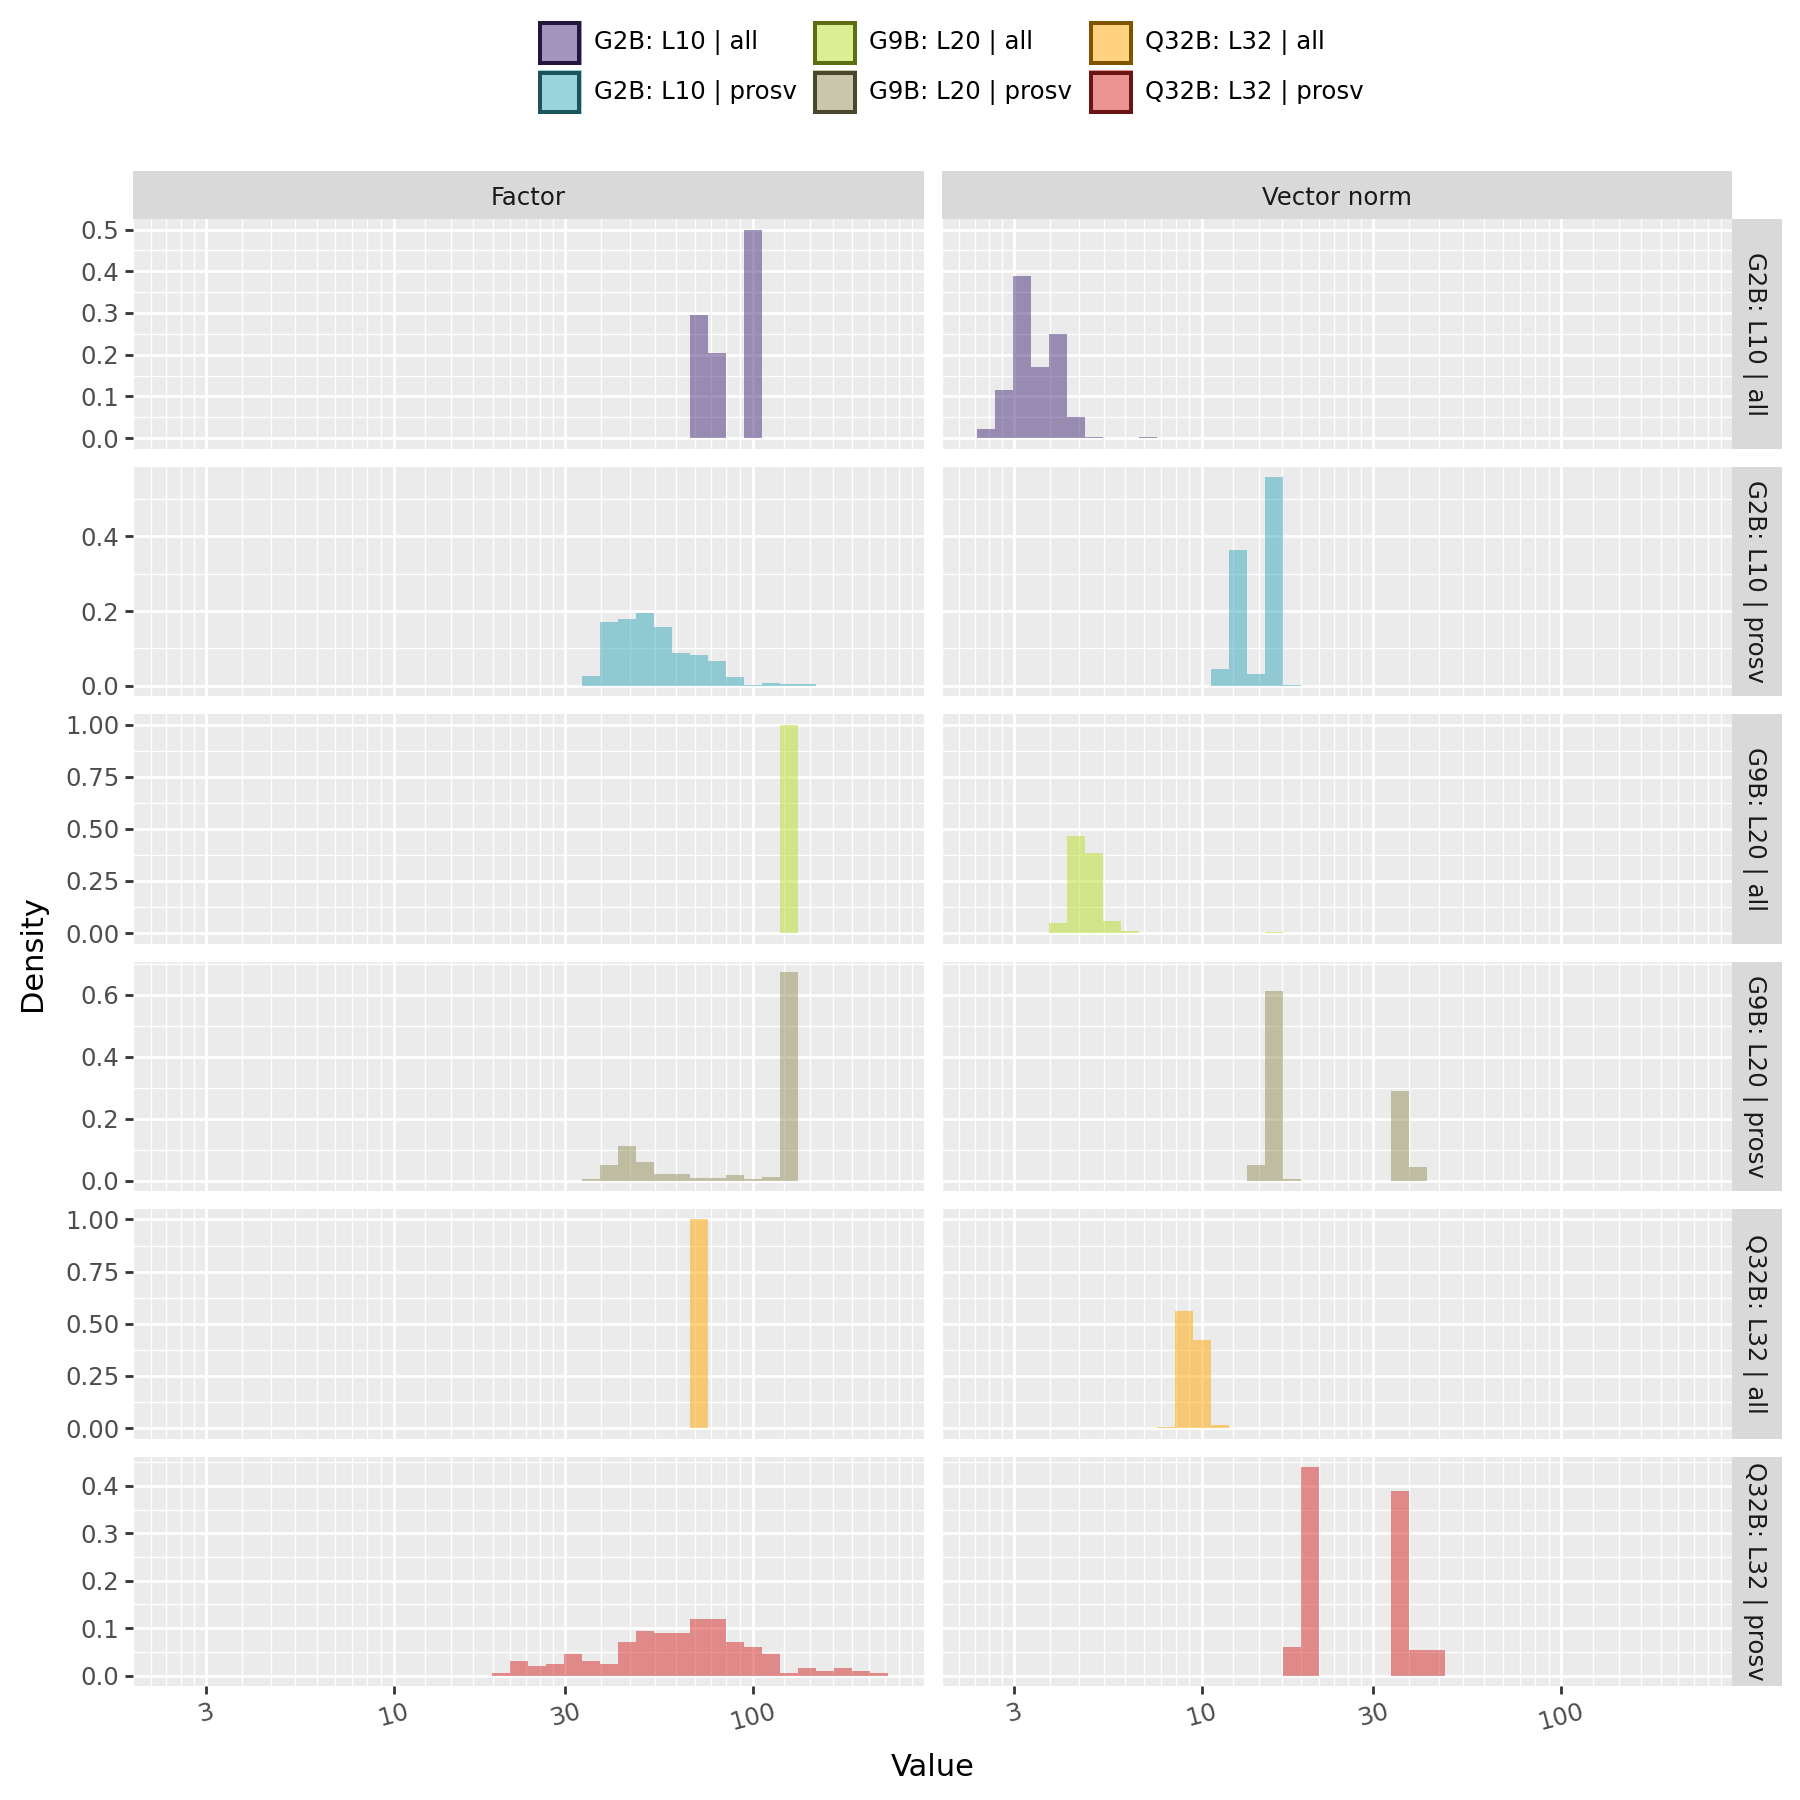

In [37]:
from plotnine import *

tmp_df = all_df.melt(
    id_vars=["cfg", "position", "objective"],
    value_vars=["factor", "l2norm"],
    var_name='size'
)
tmp_df['size'] = tmp_df['size'].replace(['factor', 'l2norm'], ['Factor', "Vector norm"])
tmp_df["position"] = tmp_df["position"].replace(["all", "f2+l2"], ["all", "prosv"])
tmp_df["cfg"] = tmp_df["cfg"].replace(
    ["2b_l10", "9b_l20", "q25_32b_l32"], ["G2B: L10", "G9B: L20", "Q32B: L32"]
)
tmp_df["cfg_position"] = tmp_df["cfg"] + " | " + tmp_df["position"]
tmp_df["cfg_position"] = pd.Categorical(
    tmp_df["cfg_position"],
    categories=[
        c + " | " + p
        for c, p in itertools.product(
            ["G2B: L10", "G9B: L20", "Q32B: L32"], ["all", "prosv"]
        )
    ],
    ordered=True,
)
metric_colors = [
    "#472d7b",
    "#39a9bc",
    "#b8de29",
    "#949158",
    "#ffa600",
    "#d62828",
]

plot = (
    # ggplot(tmp_df, aes(x="cfg_position", y="value", color="cfg_position"))
    ggplot(tmp_df, aes(x="value", y=after_stat('width*density'), fill="cfg_position"))
    + facet_grid("cfg_position ~ size", scales="free_y")
    # + geom_violin()
    + geom_histogram(position='identity', alpha=0.5, binwidth=0.05)
    # + scale_color_manual(metric_colors)
    + scale_fill_manual(metric_colors)
    + labs(x="Value", y="Density", fill="")
    + theme(
        figure_size=(9, 9),
        axis_text_x=element_text(rotation=15),
        legend_position="top",
        legend_key=element_rect(color="black", fill="white", size=0.8),
    )
    + scale_x_log10()
)
plot


In [38]:
save_dir = Path('figures/')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "factor_vecnorm_distribution.pdf"
plot.save(save_path)


/home/byt/Code/reft/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 9 x 9 in image.
/home/byt/Code/reft/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/factor_vecnorm_distribution.pdf


# Cosine similarities


In [1]:
import torch
from pathlib import Path

cfg = "2b_l10"
# cfg = "9b_l20"
# cfg = "q25_32b_l32"

# positions = "all"
positions = "f2+l2"
# positions = "f4+l4"

# obj = "lang"
pos = "simpo"

intvs = ["add_free"]

# positions = "prompt"
# obj = "none"
# intvs = ["prompt"]

output_root_dir = Path("/mnt/data/byt", "reft_data", "axbench")


In [3]:
from collections import defaultdict
import itertools
import pandas as pd


def load_ckpts(output_root_dir, cfgs, positions, objs, interventions=("add_free",)):
    res_df = defaultdict(list)

    for k, cfg, obj, pos in itertools.product(interventions, cfgs, objs, positions):
        for concept_id in range(500):
            eval_path = (
                output_root_dir
                / cfg
                / f"outputs_{k}"
                / f"{pos}"
                / obj
                / f"{concept_id}"
                / "state_dict.pt"
            )
            if not eval_path.exists():
                continue

            state_dict = torch.load(eval_path, map_location="cpu")
            if cfg == "2b_l10":
                l = 10
            elif cfg == "9b_l20":
                l = 20
            elif cfg == "q25_32b_l32":
                l = 32
            else:
                l = None
            factor = state_dict[f"model.layers.{l}"]["factor"].item()
            vector = state_dict[f"model.layers.{l}"]["proj.weight"].float().view(-1)

            res_df["method"].append(k)
            res_df["cfg"].append(cfg)
            res_df["objective"].append(obj)
            res_df["position"].append(pos)

            res_df["concept_id"].append(concept_id)
            res_df["factor"].append(factor)
            res_df["vector"].append(vector)

    res_df = pd.DataFrame(res_df)
    if len(res_df) == 0:
        return None
    res_df["method"] = res_df["method"].replace(
        ["add_free", "clamp_free"], ["AddInv", "ClampInv"]
    )
    return res_df


In [4]:
all_df = load_ckpts(
    output_root_dir=output_root_dir,
    cfgs=["2b_l10", "9b_l20", "q25_32b_l32"],
    positions=["all", "f2+l2"],
    objs=["lang", "simpo"],
    interventions=["add_free"],
)


In [5]:
def cosine_similarity(x, y):
    return torch.dot(x, y)/(x.norm() * y.norm())

def get_similarity_location(cfg):
    sim_df = defaultdict(list)

    cfg_df = all_df[(all_df['cfg']==cfg)]
    prosv_df = cfg_df[cfg_df['position']=='f2+l2']
    fssv_df = cfg_df[cfg_df['position']=='all']

    for obj in ("lang", "simpo"):
        prosv_obj_df = prosv_df[prosv_df['objective']==obj]
        fssv_obj_df = fssv_df[fssv_df['objective']==obj]
        n = min(len(prosv_obj_df), len(fssv_obj_df))
        for i in range(n):
            cos = cosine_similarity(prosv_obj_df.iloc[i]['vector'], fssv_obj_df.iloc[i]['vector']).item()

            sim_df['type'].append('Location: FSSV vs. PrOSV')
            sim_df['cfg'].append(cfg)
            sim_df['sim'].append(cos)
            sim_df['sv'].append('\\')
            sim_df['obj'].append('Lang.' if obj == "lang" else "SimPO")

    sim_df = pd.DataFrame(sim_df)
    return sim_df

def get_similarity_objective(cfg):
    sim_df = defaultdict(list)

    cfg_df = all_df[(all_df['cfg']==cfg)]
    lang_df = cfg_df[cfg_df['objective']=='lang']
    simpo_df = cfg_df[cfg_df['objective']=='simpo']

    for pos in ("all", "f2+l2"):
        prosv_obj_df = lang_df[lang_df['position']==pos]
        fssv_obj_df = simpo_df[simpo_df['position']==pos]
        n = min(len(prosv_obj_df), len(fssv_obj_df))
        for i in range(n):
            cos = cosine_similarity(prosv_obj_df.iloc[i]['vector'], fssv_obj_df.iloc[i]['vector']).item()

            sim_df['type'].append('Objective: Lang. vs. SimPO')
            sim_df['cfg'].append(cfg)
            sim_df['sim'].append(cos)
            sim_df['sv'].append('FSSV' if pos=='all' else 'PrOSV')
            sim_df['obj'].append('\\')

    sim_df = pd.DataFrame(sim_df)
    return sim_df


sim_df = pd.concat(
    [get_similarity_location(cfg) for cfg in ["2b_l10", "9b_l20", "q25_32b_l32"]]
    + [get_similarity_objective(cfg) for cfg in ["2b_l10", "9b_l20", "q25_32b_l32"]]
)


/home/byt/Code/reft/.venv/lib/python3.10/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 11'. Pick better value with 'binwidth'.


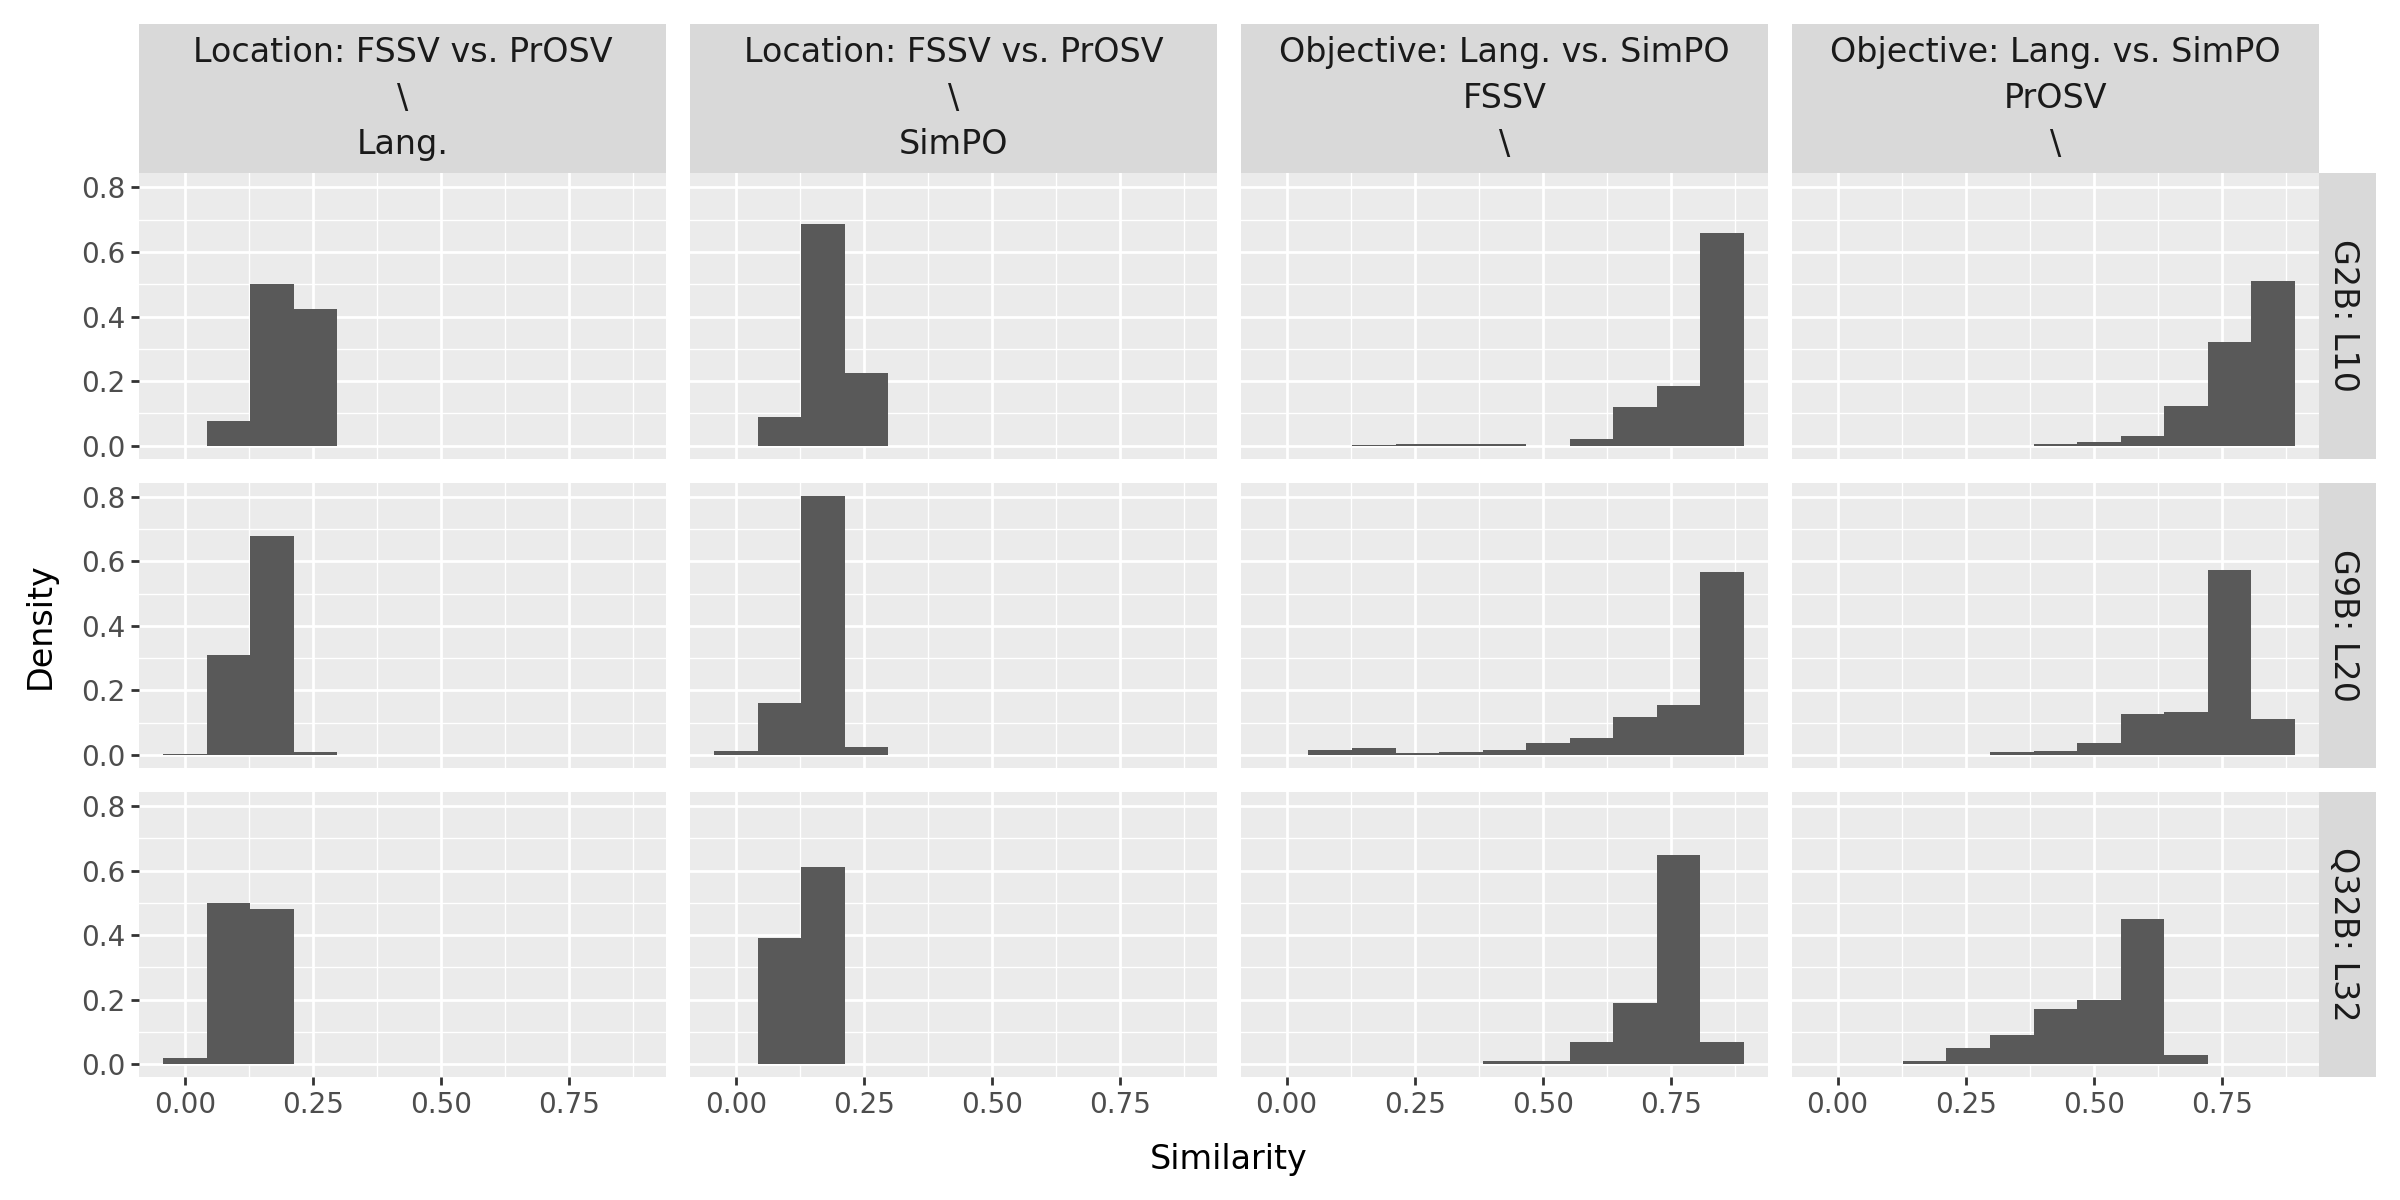

In [6]:
from plotnine import *

sim_df["cfg"] = sim_df["cfg"].replace(
    ["2b_l10", "9b_l20", "q25_32b_l32"], ["G2B: L10", "G9B: L20", "Q32B: L32"]
)

plot = (
    ggplot(sim_df, aes(x="sim"))
    + facet_grid("cfg~type + sv + obj")
    + geom_histogram(aes(y=after_stat("width*density")))
    + theme(
        figure_size=(12, 6),
        strip_text=element_text(size=12),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
    )
    + labs(x="Similarity", y="Density")
)
plot


In [7]:
save_dir = Path('figures/')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "cosine_similarity.pdf"
plot.save(save_path)


/home/byt/Code/reft/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/home/byt/Code/reft/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/cosine_similarity.pdf
/home/byt/Code/reft/.venv/lib/python3.10/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 11'. Pick better value with 'binwidth'.
